In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
%matplotlib inline

In [2]:
#нормализация
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.1307,), (0.3081,))])

#загрузка данных для тренировки
mnist_train = torchvision.datasets.MNIST("./mnist/", train=True, download=True, transform=transform)
mnist_val = torchvision.datasets.MNIST("./mnist/", train=False, download=True, transform=transform)

#поднял до 64
train_dataloader = DataLoader(mnist_train, batch_size=64, shuffle=True)
val_dataloader = DataLoader(mnist_val, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 7.84MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 209kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.33MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.9MB/s]


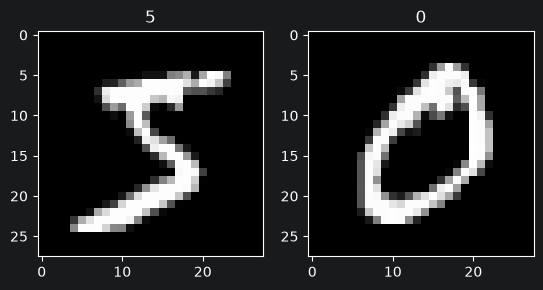

In [3]:
for i in [0, 1]:
    plt.subplot(1, 2, i + 1)
    plt.imshow(mnist_train[i][0].squeeze(0).numpy(), cmap="gray")
    plt.title(str(mnist_train[i][1]))
plt.show()

In [4]:
#добавил второй слой и dropout
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 10),
)

#SGD заменили на Adam
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [5]:
# 10 эпох
epochs = 10

for epoch in range(epochs):
    model.train()  #перевод модели в режим обучения
    for x_train, y_train in tqdm(train_dataloader):
        y_pred = model(x_train)
        loss = F.cross_entropy(y_pred, y_train)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    #валидация
    model.eval() #перевод модели в режим оценки
    val_loss = []
    val_accuracy = []
    with torch.no_grad():
        for x_val, y_val in val_dataloader:
            y_pred = model(x_val)
            loss = F.cross_entropy(y_pred, y_val)
            val_loss.append(loss.numpy())
            val_accuracy.extend((torch.argmax(y_pred, dim=-1) == y_val).numpy().tolist())

    #печатаем метрики
    print(f"Epoch: {epoch}, loss: {np.mean(val_loss):.4f}, "f"accuracy: {np.mean(val_accuracy):.4f}")

100%|██████████| 938/938 [00:09<00:00, 99.41it/s] 


Epoch: 0, loss: 0.1252, accuracy: 0.9622


100%|██████████| 938/938 [00:09<00:00, 102.28it/s]


Epoch: 1, loss: 0.0873, accuracy: 0.9720


100%|██████████| 938/938 [00:09<00:00, 103.32it/s]


...

Epoch: 7, loss: 0.0605, accuracy: 0.9810


100%|██████████| 938/938 [00:08<00:00, 104.86it/s]


Epoch: 8, loss: 0.0798, accuracy: 0.9775


100%|██████████| 938/938 [00:09<00:00, 103.98it/s]


Epoch: 9, loss: 0.0665, accuracy: 0.9820
